In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [10]:
def parse_log_file(filepath):
    """
    Reads a text log file and converts it into a pandas DataFrame.
    """
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return pd.DataFrame()
        
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = [p.strip() for p in line.split('|')]
            
            # Skip invalid or incomplete lines
            if len(parts) < 8:
                continue
            
            try:
                # Parse hyperparameters
                model = parts[0].split(':')[1].strip().lower() # Make model name lowercase for consistency
                hidden = int(parts[1].split(':')[1].strip())
                seq = int(parts[3].split(':')[1].strip())
                
                # Extract 'Time' (Inference or Backprop)
                time_str = parts[6].split(':')[1].strip().replace('s', '')
                time_val = float(time_str)
                
                # Extract 'Peak VRAM'
                vram_str = parts[7].split(':')[1].strip().replace('MB', '')
                vram_val = float(vram_str)
                
                # Append to data list
                data.append({
                    'Model': model,
                    'Hidden': hidden,
                    'Seq': seq,
                    'Time': time_val,
                    'VRAM': vram_val
                })
            except Exception as e:
                print(f"Error parsing line: {line}\nException: {e}")
                continue
                
    return pd.DataFrame(data)

def plot_benchmark(hidden_size, mode, metric="time"):
    """
    Plots the benchmark results comparing different models for a fixed hidden size.
    
    Args:
        hidden_size (int): The fixed hidden size to plot (e.g., 256)
        mode (str): "inference" or "backprop"
        metric (str): "time" or "vram" (determines the y-axis)
    """
    mode = mode.lower()
    metric = metric.lower()
    
    # Determine the file path based on the mode
    if mode == "inference":
        filepath = "./inference_time.txt"
        mode_title = "Inference"
    elif mode == "backprop":
        filepath = "./backprop_time.txt"
        mode_title = "Backpropagation"
    else:
        raise ValueError("Mode must be either 'inference' or 'backprop'")
        
    df = parse_log_file(filepath)
    if df.empty:
        return
        
    # Filter data for the specified hidden size
    df_filtered = df[df['Hidden'] == hidden_size].copy()
    if df_filtered.empty:
        print(f"No data found for hidden size '{hidden_size}' in {filepath}")
        return
        
    # Set up visualization parameters based on the metric
    plt.figure(figsize=(10, 6))
    
    if metric == "time":
        y_col = 'Time'
        y_label = "Time (seconds)"
        title = f"Hidden Size {hidden_size}: Max Seq Length vs {mode_title} Time"
    elif metric == "vram":
        y_col = 'VRAM'
        y_label = "Peak VRAM (MB)"
        title = f"Hidden Size {hidden_size}: Max Seq Length vs {mode_title} Peak VRAM"
    else:
        raise ValueError("Metric must be either 'time' or 'vram'")
        
    # Group by model name and plot
    models = sorted(df_filtered['Model'].unique())
    
    for m in models:
        # Extract data for the current model and sort by Sequence length
        subset = df_filtered[df_filtered['Model'] == m].sort_values(by='Seq')
        
        # Line plot with markers
        plt.plot(subset['Seq'], subset[y_col], marker='o', linewidth=2, label=f'Model: {m.upper()}')
        
    # Decorate the plot
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Max Sequence Length", fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title="Architecture", loc='upper left')
    plt.tight_layout()
    
    # Display the plot
    plt.show()

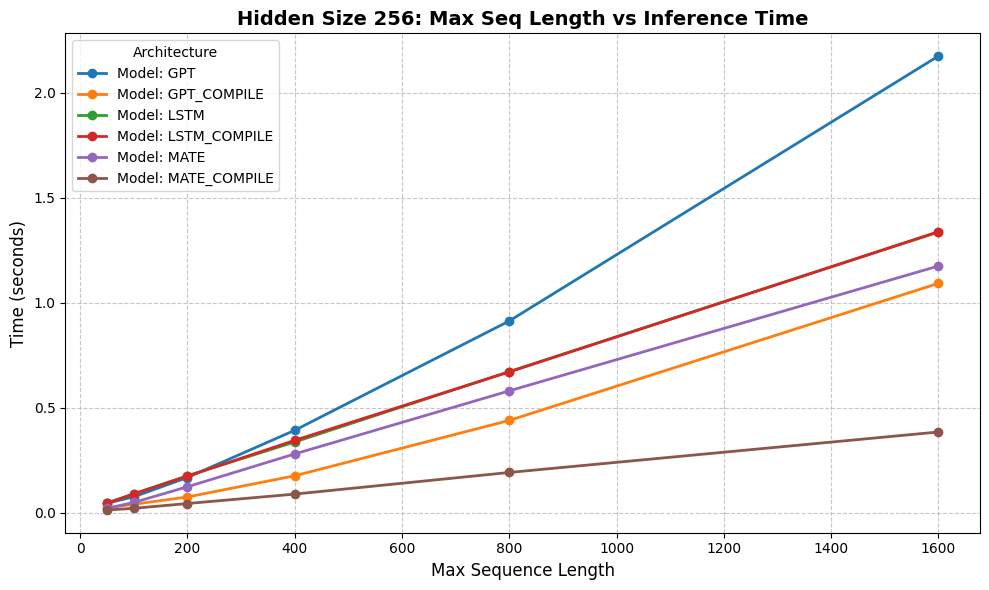

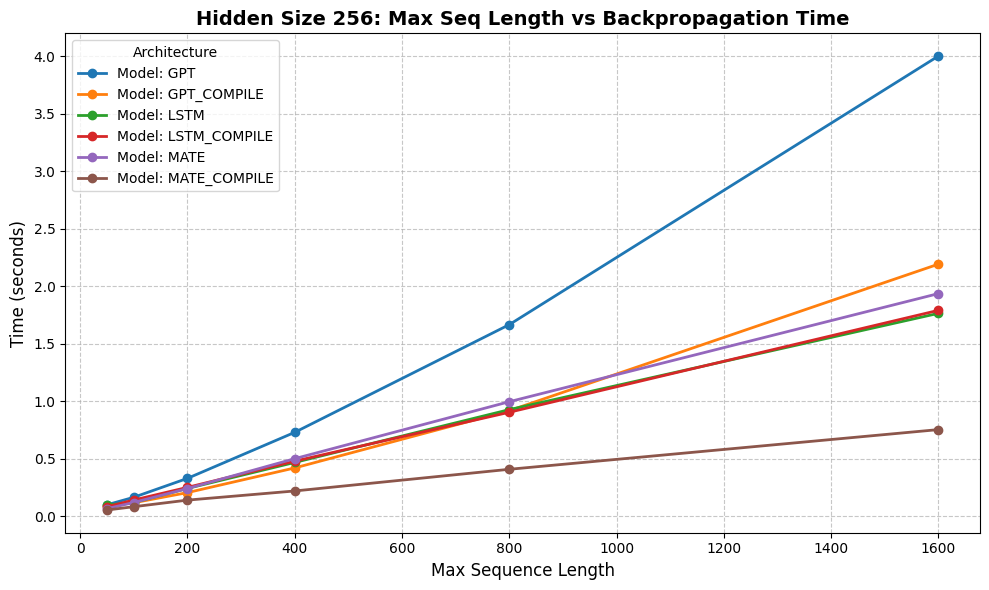

In [15]:
# Plot Inference Time comparing models at hidden_size=256
plot_benchmark(hidden_size=256, mode="inference", metric="time")

# Plot Backprop Time comparing models at hidden_size=256
plot_benchmark(hidden_size=256, mode="backprop", metric="time")

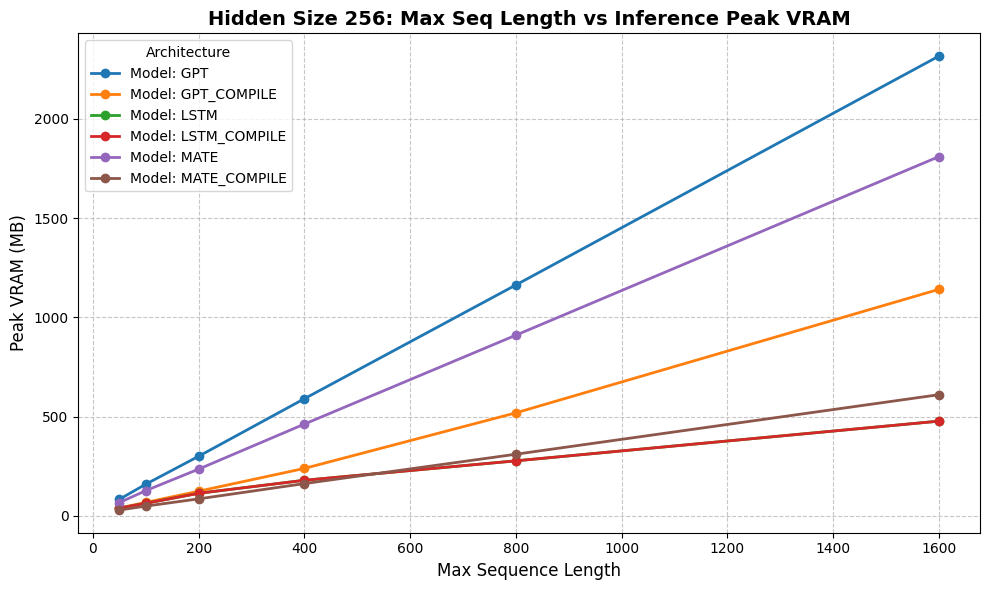

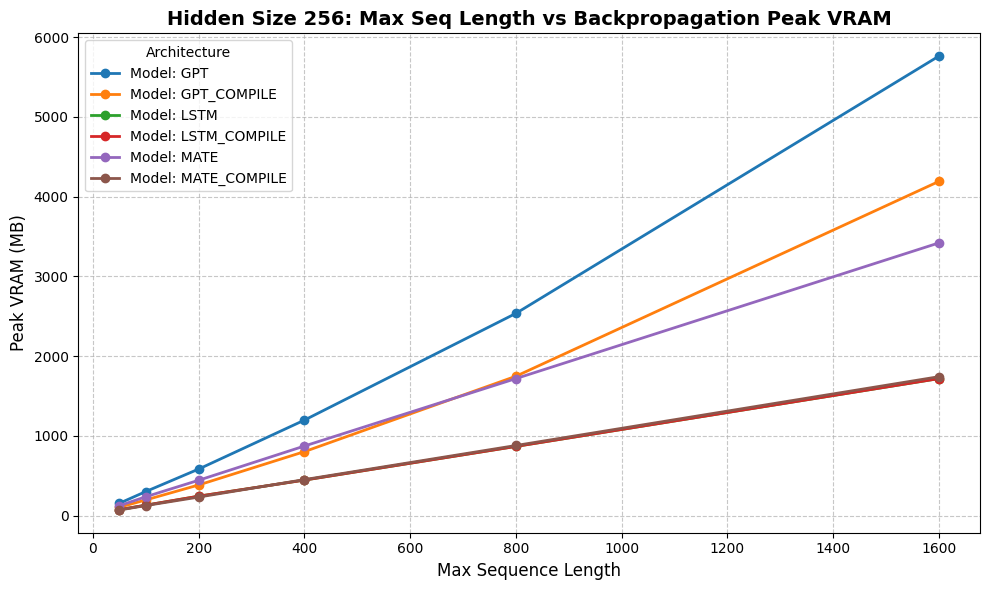

In [16]:
# Plot Peak VRAM during Inference comparing models at hidden_size=256
plot_benchmark(hidden_size=256, mode="inference", metric="vram")

# Plot Peak VRAM during Backprop comparing models at hidden_size=256
plot_benchmark(hidden_size=256, mode="backprop", metric="vram")